# Simple Architecture: Baseline and Failure Analysis

This notebook isolates the original simple encoder-decoder architecture and documents why it did not produce a usable clean baseline.

The goal is not to repeat every expensive training run, but to preserve a reproducible model definition, verified historical metrics, training curves, and concrete decoding failures. Success is defined as validation BER below `0.2` with acceptable image quality. The test split is not used.

In [1]:
import json
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data import get_dataloaders
from src.train import train_one_epoch, validate
from src.utils import SEED, set_seed

set_seed()
EVALUATION_DEVICE = torch.device("cpu")

print(f"Seed: {SEED}")
print(f"Evaluation device: {EVALUATION_DEVICE}")

Seed: 95
Evaluation device: cpu


## Data Preparation

We use the same fixed split as in the other experiments: 4,000 training images, 500 validation images, and 500 reserved test images. Images are proportionally resized to `128x128` and padded, while the content mask identifies the actual image area.

The transformation does not learn any parameters from the data. The test loader is not used for model selection or for any metrics in this notebook.

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_FILE = DATA_DIR / "splits.json"

with SPLITS_FILE.open("r", encoding="utf-8") as split_file:
    splits = json.load(split_file)

train_loader, val_loader, _ = get_dataloaders(
    DATA_DIR,
    SPLITS_FILE,
    batch_size=16,
    num_workers=0,
)

sample_images, sample_masks = next(iter(val_loader))

print(f"Train images: {len(splits['train'])}")
print(f"Validation images: {len(splits['val'])}")
print(f"Reserved test images: {len(splits['test'])}")
print(f"Image batch shape: {tuple(sample_images.shape)}")
print(f"Mask batch shape: {tuple(sample_masks.shape)}")

Train images: 4000
Validation images: 500
Reserved test images: 500
Image batch shape: (16, 3, 128, 128)
Mask batch shape: (16, 1, 128, 128)


## Simple Architecture Definition

### Simple Encoder

The message is spatially expanded and immediately concatenated with the RGB image. Three `Conv2d-ReLU` layers then directly produce an image residual. In the constrained 16-bit experiment, the residual was limited with `0.03 * tanh(raw_residual)` and applied only inside the content mask.

### Simple Decoder

The decoder uses three `Conv2d-ReLU-MaxPool` blocks. Resolution is reduced as `128x128 -> 64x64 -> 32x32 -> 16x16`, followed by global average pooling and a linear output layer. The content mask was not used during decoding.

In [3]:
class SimpleWatermarkEncoder(nn.Module):
    def __init__(
        self,
        message_length=16,
        image_channels=3,
        feature_channels=(64, 64, 32),
        max_delta=0.03,
    ):
        super().__init__()
        self.message_length = message_length
        self.max_delta = max_delta

        channels1, channels2, channels3 = feature_channels
        self.conv1 = nn.Conv2d(
            image_channels + message_length,
            channels1,
            kernel_size=3,
            padding=1,
        )
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(channels1, channels2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(channels2, channels3, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv_out = nn.Conv2d(channels3, image_channels, kernel_size=3, padding=1)

    def forward(self, images, messages, masks):
        height, width = images.shape[-2:]
        expanded_messages = messages.unsqueeze(-1).unsqueeze(-1).expand(
            -1,
            -1,
            height,
            width,
        )
        features = torch.cat([images, expanded_messages], dim=1)

        features = self.relu1(self.conv1(features))
        features = self.relu2(self.conv2(features))
        features = self.relu3(self.conv3(features))

        residual = self.conv_out(features)
        if self.max_delta is not None:
            residual = self.max_delta * torch.tanh(residual)

        return torch.clamp(images + residual * masks, 0.0, 1.0)

In [4]:
class SimpleWatermarkDecoder(nn.Module):
    def __init__(
        self,
        message_length=16,
        feature_channels=(32, 64, 128),
    ):
        super().__init__()
        channels1, channels2, channels3 = feature_channels

        self.conv1 = nn.Conv2d(3, channels1, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(channels1, channels2, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(channels2, channels3, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.fc = nn.Linear(channels3, message_length)

    def forward(self, images, masks=None):
        features = self.pool1(self.relu1(self.conv1(images)))
        features = self.pool2(self.relu2(self.conv2(features)))
        features = self.pool3(self.relu3(self.conv3(features)))
        features = features.mean(dim=(2, 3))
        return self.fc(features)

In [5]:
simple_encoder = SimpleWatermarkEncoder()
simple_decoder = SimpleWatermarkDecoder()

images = sample_images[:2]
masks = sample_masks[:2]
messages = torch.randint(
    0,
    2,
    (len(images), 16),
    generator=torch.Generator().manual_seed(SEED),
    dtype=torch.float32,
 )

with torch.no_grad():
    watermarked = simple_encoder(images, messages, masks)
    logits = simple_decoder(watermarked)

encoder_parameters = sum(parameter.numel() for parameter in simple_encoder.parameters())
decoder_parameters = sum(parameter.numel() for parameter in simple_decoder.parameters())

print(f"Watermarked images: {tuple(watermarked.shape)}")
print(f"Decoder logits: {tuple(logits.shape)}")
print(f"Encoder parameters: {encoder_parameters:,}")
print(f"Decoder parameters: {decoder_parameters:,}")
print(f"Total parameters: {encoder_parameters + decoder_parameters:,}")

Watermarked images: (2, 3, 128, 128)
Decoder logits: (2, 16)
Encoder parameters: 67,267
Decoder parameters: 95,312
Total parameters: 162,579


## Training the Simple Model

The code below is a minimal reproduction of the constrained 16-bit training setup: Adam with a learning rate of `1e-3`, batch size 16, message loss only, `max_delta=0.03`, and no noise.

Full retraining is disabled by default because the experiments have already been completed and their verified metrics are embedded in the next section. Setting `RUN_FULL_REPRODUCTION = True` starts a new 20-epoch run on the complete training and validation splits.

In [6]:
def train_simple_model(epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    encoder = SimpleWatermarkEncoder().to(device)
    decoder = SimpleWatermarkDecoder().to(device)
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=1e-3,
    )
    criterion = nn.BCEWithLogitsLoss()

    validation_messages = torch.randint(
        0,
        2,
        (len(val_loader.dataset), 16),
        generator=torch.Generator().manual_seed(SEED),
        dtype=torch.float32,
    )

    records = []
    for epoch in range(epochs):
        train_stats = train_one_epoch(
            encoder,
            decoder,
            train_loader,
            optimizer,
            criterion,
            device,
            message_length=16,
            image_loss_weight=0.0,
            attack_configs=None,
        )
        val_stats = validate(
            encoder,
            decoder,
            val_loader,
            criterion,
            device,
            message_length=16,
            image_loss_weight=0.0,
            attack_configs=None,
            fixed_messages=validation_messages,
        )

        records.append({
            "epoch": epoch + 1,
            **{f"train_{name}": value for name, value in train_stats.items()},
            **{f"val_{name}": value for name, value in val_stats.items()},
        })
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_BER={train_stats['ber']:.4f} | "
            f"val_BER={val_stats['ber']:.4f} | "
            f"val_PSNR={val_stats['psnr']:.2f}"
        )

    return encoder, decoder, pd.DataFrame(records)


RUN_FULL_REPRODUCTION = False

if RUN_FULL_REPRODUCTION:
    reproduced_encoder, reproduced_decoder, reproduced_history = train_simple_model()
else:
    print("Full reproduction skipped; using the verified historical results below.")

Full reproduction skipped; using the verified historical results below.


## Evaluation of Historical Experiments

For every experiment, we preserve two BER values:

- `selected_ber`: BER of the checkpoint selected by minimum validation loss;
- `minimum_ber`: the lowest BER observed anywhere in the experiment log.

These values do not necessarily come from the same epoch. This prevents a favorable BER fluctuation from being presented as the checkpoint that was actually selected during the experiment.

In [7]:
baseline_results = pd.DataFrame(
    [
        {
            "experiment": "Message-only (32 bit)",
            "selected_epoch": 38,
            "selected_ber": 0.3709375,
            "minimum_ber": 0.3656875,
            "minimum_ber_epoch": 40,
            "selected_psnr": 7.4393,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "Image weight 0.03",
            "selected_epoch": 20,
            "selected_ber": 0.4084375,
            "minimum_ber": 0.4076875,
            "minimum_ber_epoch": 5,
            "selected_psnr": 11.1468,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "Image weight 0.10",
            "selected_epoch": 20,
            "selected_ber": 0.4381250,
            "minimum_ber": 0.4275625,
            "minimum_ber_epoch": 9,
            "selected_psnr": 15.2725,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "Image weight 0.30",
            "selected_epoch": 18,
            "selected_ber": 0.4314375,
            "minimum_ber": 0.4314375,
            "minimum_ber_epoch": 18,
            "selected_psnr": 19.1571,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "Small model (40 epochs)",
            "selected_epoch": 40,
            "selected_ber": 0.4390000,
            "minimum_ber": 0.4281250,
            "minimum_ber_epoch": 14,
            "selected_psnr": 20.9463,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "Wide model",
            "selected_epoch": 4,
            "selected_ber": 0.4914375,
            "minimum_ber": 0.4914375,
            "minimum_ber_epoch": 4,
            "selected_psnr": 66.4783,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "16 bit, max pool, delta 0.03",
            "selected_epoch": 17,
            "selected_ber": 0.4643750,
            "minimum_ber": 0.4328750,
            "minimum_ber_epoch": 5,
            "selected_psnr": 30.5625,
            "exact_accuracy": 0.0,
        },
        {
            "experiment": "16 bit, avg pool, delta 0.03",
            "selected_epoch": 19,
            "selected_ber": 0.4488750,
            "minimum_ber": 0.4473750,
            "minimum_ber_epoch": 20,
            "selected_psnr": 30.5471,
            "exact_accuracy": 0.0,
        },
    ]
)

baseline_results.round(4)

,experiment,selected_epoch,selected_ber,minimum_ber,minimum_ber_epoch,selected_psnr,exact_accuracy
0,Message-only (32 bit),38,0.3709,0.3657,40,7.4393,0.0
1,Image weight 0.03,20,0.4084,0.4077,5,11.1468,0.0
2,Image weight 0.10,20,0.4381,0.4276,9,15.2725,0.0
3,Image weight 0.30,18,0.4314,0.4314,18,19.1571,0.0
4,Small model (40 epochs),40,0.4390,0.4281,14,20.9463,0.0
5,Wide model,4,0.4914,0.4914,4,66.4783,0.0
6,"16 bit, max pool, delta 0.03",17,0.4644,0.4329,5,30.5625,0.0
7,"16 bit, avg pool, delta 0.03",19,0.4489,0.4474,20,30.5471,0.0


## Training Visualization

The left plot shows the BER-PSNR trade-off for the selected checkpoints. The ideal point would be near the bottom-right corner: low BER and high PSNR.

The right plot loads complete local CSV logs for the bounded 16-bit experiments when they are available. They are not required for the table or conclusion, but they show that BER remains far above the target throughout training.

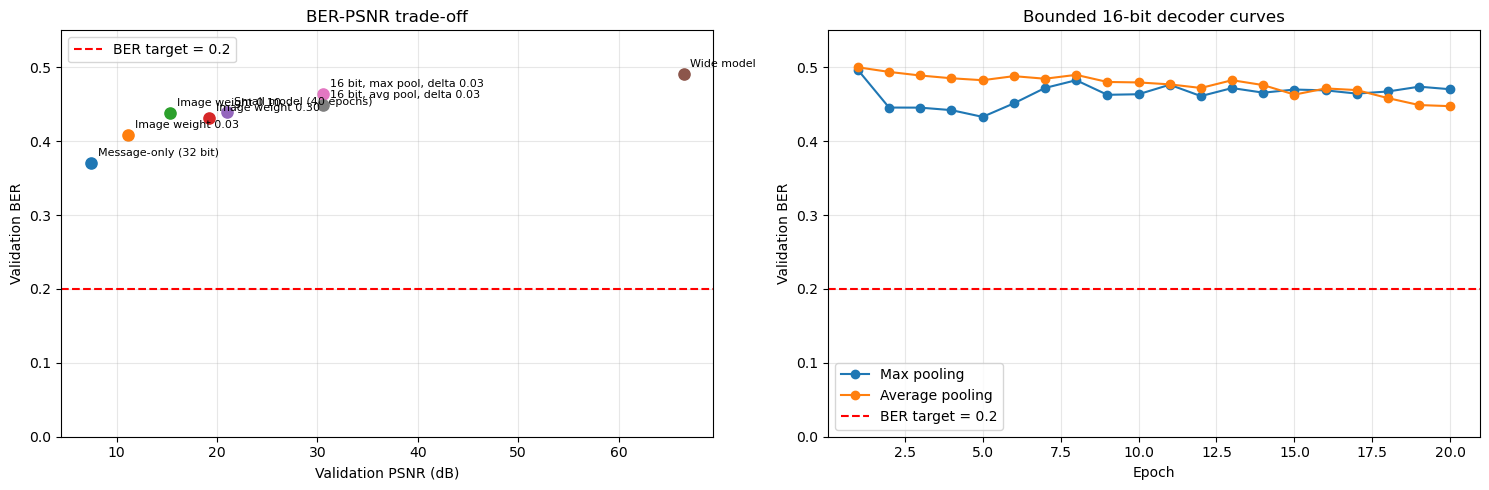

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for _, row in baseline_results.iterrows():
    axes[0].scatter(row["selected_psnr"], row["selected_ber"], s=65)
    axes[0].annotate(
        row["experiment"],
        (row["selected_psnr"], row["selected_ber"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

axes[0].axhline(0.2, color="red", linestyle="--", label="BER target = 0.2")
axes[0].set_xlabel("Validation PSNR (dB)")
axes[0].set_ylabel("Validation BER")
axes[0].set_title("BER-PSNR trade-off")
axes[0].set_ylim(0.0, 0.55)
axes[0].grid(alpha=0.3)
axes[0].legend()

curve_specs = [
    ("baseline-16bit-delta-0.03.csv", "Max pooling"),
    ("baseline-16bit-avg-delta-0.03.csv", "Average pooling"),
]
curves_found = False

for file_name, label in curve_specs:
    log_path = PROJECT_ROOT / "results" / "logs" / file_name
    if log_path.exists():
        curve = pd.read_csv(log_path)
        axes[1].plot(curve["epoch"], curve["val_ber"], marker="o", label=label)
        curves_found = True

axes[1].axhline(0.2, color="red", linestyle="--", label="BER target = 0.2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation BER")
axes[1].set_title("Bounded 16-bit decoder curves")
axes[1].set_ylim(0.0, 0.55)
axes[1].grid(alpha=0.3)

if curves_found:
    axes[1].legend()
else:
    axes[1].text(
        0.5,
        0.5,
        "Detailed local CSV logs are not available.",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )

fig.tight_layout()
plt.show()

## Evaluation and Failure Demonstration

A practical baseline must achieve validation BER below `0.2`. The code below checks selected checkpoints with PSNR of at least 30 dB, excluding models that lower BER only by severely damaging the image.

We also check exact message accuracy. It remained zero in every full-dataset experiment with the simple architecture.

In [9]:
SUCCESS_BER = 0.2
MINIMUM_ACCEPTABLE_PSNR = 30.0

practical_results = baseline_results[
    baseline_results["selected_psnr"] >= MINIMUM_ACCEPTABLE_PSNR
]
best_practical_result = practical_results.loc[
    practical_results["selected_ber"].idxmin()
]
baseline_passes = best_practical_result["selected_ber"] < SUCCESS_BER

print(f"Best practical experiment: {best_practical_result['experiment']}")
print(f"Selected validation BER: {best_practical_result['selected_ber']:.4f}")
print(f"Selected validation PSNR: {best_practical_result['selected_psnr']:.2f} dB")
print(f"Required BER: < {SUCCESS_BER}")
print(f"Baseline passes: {baseline_passes}")

assert not baseline_passes
assert (baseline_results["exact_accuracy"] == 0).all()

Best practical experiment: 16 bit, avg pool, delta 0.03
Selected validation BER: 0.4489
Selected validation PSNR: 30.55 dB
Required BER: < 0.2
Baseline passes: False


## Analysis of Problematic Examples

When the historical checkpoint is available locally, the next cell displays four validation images with the largest number of incorrect bits in the first batch. For each image, we show the original, its watermarked version, the expected message, and the prediction.

The checkpoint belongs to the 16-bit max-pooling model with `max_delta=0.03`. The cell uses the CPU to avoid occupying the GPU during other experiments.

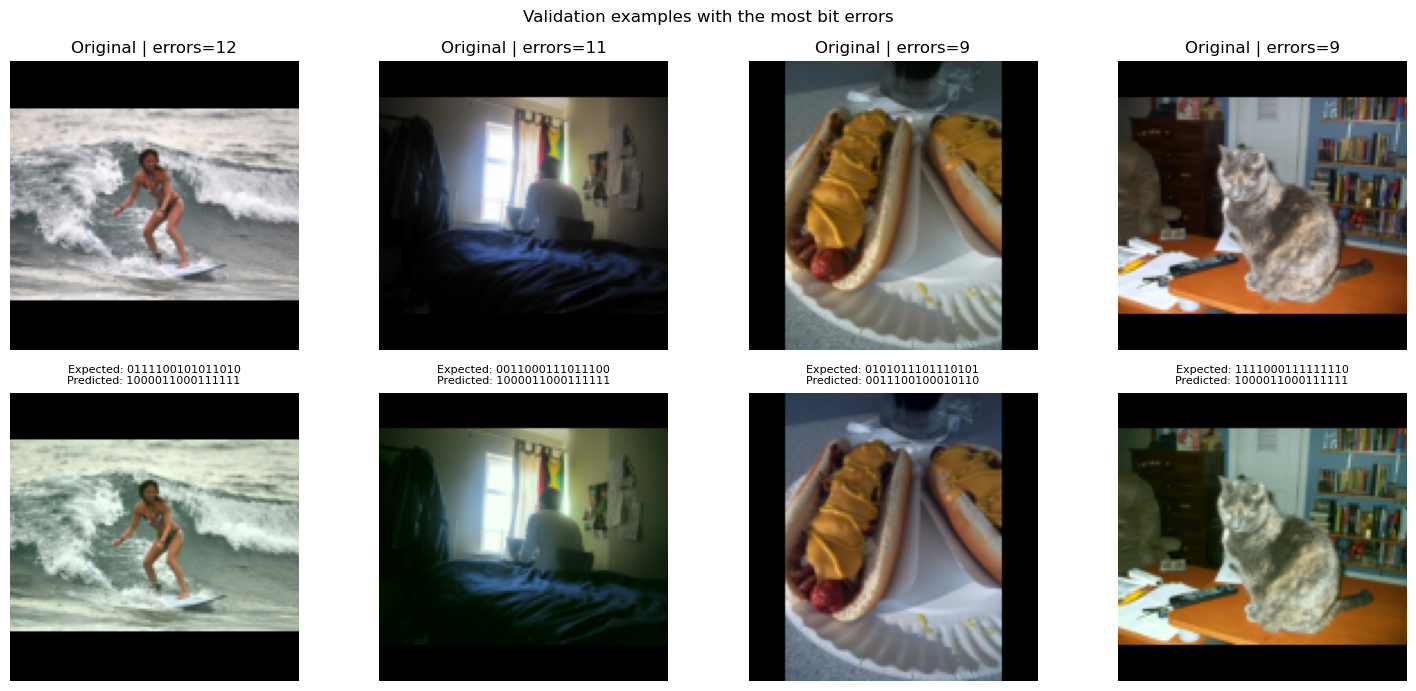

In [10]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "baseline-16bit-delta-0.03"
    / "best_model.pt"
)

if checkpoint_path.exists():
    checkpoint = torch.load(
        checkpoint_path,
        map_location=EVALUATION_DEVICE,
        weights_only=False,
    )
    example_encoder = SimpleWatermarkEncoder().to(EVALUATION_DEVICE)
    example_decoder = SimpleWatermarkDecoder().to(EVALUATION_DEVICE)
    example_encoder.load_state_dict(checkpoint["encoder_state_dict"])
    example_decoder.load_state_dict(checkpoint["decoder_state_dict"])
    example_encoder.eval()
    example_decoder.eval()

    example_images, example_masks = next(iter(val_loader))
    example_images = example_images.to(EVALUATION_DEVICE)
    example_masks = example_masks.to(EVALUATION_DEVICE)
    example_messages = torch.randint(
        0,
        2,
        (len(example_images), 16),
        generator=torch.Generator().manual_seed(SEED),
        dtype=torch.float32,
    ).to(EVALUATION_DEVICE)

    with torch.no_grad():
        example_watermarked = example_encoder(
            example_images,
            example_messages,
            example_masks,
        )
        example_logits = example_decoder(example_watermarked)
        predicted_messages = (example_logits >= 0).to(torch.int64)

    bit_errors = (
        predicted_messages != example_messages.to(torch.int64)
    ).sum(dim=1)
    worst_indices = torch.topk(bit_errors, k=4).indices

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    for column, index in enumerate(worst_indices.tolist()):
        original = example_images[index].permute(1, 2, 0).cpu()
        marked = example_watermarked[index].permute(1, 2, 0).cpu()
        expected = "".join(str(bit) for bit in example_messages[index].int().tolist())
        predicted = "".join(str(bit) for bit in predicted_messages[index].tolist())

        axes[0, column].imshow(original)
        axes[0, column].set_title(f"Original | errors={bit_errors[index].item()}")
        axes[1, column].imshow(marked)
        axes[1, column].set_title(f"Expected: {expected}\nPredicted: {predicted}", fontsize=8)

        axes[0, column].axis("off")
        axes[1, column].axis("off")

    fig.suptitle("Validation examples with the most bit errors")
    fig.tight_layout()
    plt.show()
else:
    print(
        "Historical checkpoint is not available locally. "
        "The embedded metrics above remain reproducible without it."
    )

## Conclusion: Why the Baseline Failed

The experiments provide three clear observations:

1. The message-only model lowers BER, but at PSNR `7.44 dB`, meaning that it learns the message through an unacceptably large image distortion.
2. When image quality becomes acceptable, full-dataset BER remains approximately `0.4-0.5`, while exact message accuracy remains zero.
3. Increasing channel count, training the smaller model for more epochs, and replacing max pooling with average pooling do not solve the problem.

The most likely architectural explanation is that the message is introduced before visual features are extracted, while the shallow decoder discards the weak spatially distributed signal through three pooling operations. The absence of BatchNorm also makes stable deeper processing more difficult.

Tiny-set BER of zero shows that the implementation and gradients work. We therefore interpret the full-dataset failure as a generalization problem of the architecture under a subtle watermark constraint, rather than a broken training pipeline.

This diagnosis is supported by controlled experiments, but it is not an isolated causal proof for every component. Such proof would require a separate ablation experiment in which only one component is changed at a time.

## Transition to the HiDDeN-Inspired Architecture

The results in this notebook motivated the following changes: image processing before message fusion, deeper full-resolution blocks, BatchNorm, removal of local pooling, and masked global average pooling.

The implementation, tiny-set check, and training of the new architecture are available in [02_training.ipynb](02_training.ipynb). Detailed historical CSV logs and checkpoints remain available locally under `../results/logs` and `../results/checkpoints`; the `results` directory is Git-ignored.